In [1]:
import torch
import matplotlib.pyplot as plt
from torch import optim, distributions, nn
from tqdm.notebook import tqdm
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_RBF
from gpzoo.gp import GaussianPrior, SVGP, VNNGP, MGGP_WSVGP, WSVGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2
from gpzoo.utilities import whitened_KL, train_hybrid, train_hybrid_batched, anndata_to_train_val, plot_factors, rescale_spatial_coords, add_jitter, init_softplus
import squidpy as sq
import numpy as np
from sklearn.decomposition import NMF
import scanpy as sc
import random

from gpzoo.utilities import regularized_nmf, dims_autocorr
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pickle
from sklearn.cluster import KMeans
import matplotlib.patheffects as path_effects


/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=1)

In [3]:
adata = sq.datasets.visium_hne_adata()

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


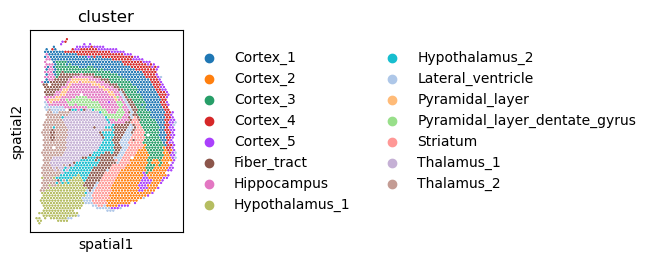

In [4]:
sq.pl.spatial_scatter(adata, color="cluster", size=1, shape=None);


<Axes: >

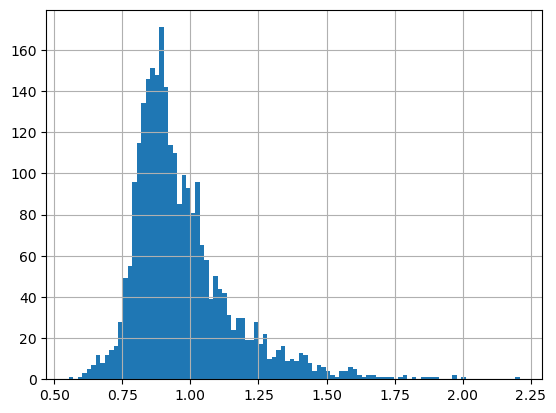

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.pct_counts_mt.hist(bins=100)

In [6]:
Dtr, Dval = anndata_to_train_val(adata, sz="scanpy")

In [7]:
Y = Dtr['Y'].T
X = Dtr['X']*50
V = Dtr['sz']

In [8]:
class ChromGP(nn.Module):
    def __init__(self, gp, kernel, noise=0.1, Z_noise=0.1, jitter=1e-5):
        super().__init__()
        self.gp = gp
        self.kernel = kernel
        self.jitter = jitter
        self.noise = nn.Parameter(torch.log(torch.exp(torch.tensor(noise)) - 1))
        # self.Z_noise = nn.Parameter(torch.log(torch.exp(torch.tensor(Z_noise)) - 1))

    def forward(self, X, E=1, verbose=False, **kwargs):
        N = len(X)
        noise = torch.nn.functional.softplus(self.noise) #ensure positive
        # Z_noise = torch.nn.functional.softplus(self.Z_noise)

        qZ, qU, pU = self.gp(X, verbose=verbose, **kwargs)
        # qZ_noise = distributions.Normal(qZ.mean, qZ.scale + Z_noise)
        # Z = qZ_noise.rsample().T
        Z = qZ.rsample().T
        Z = torch.squeeze(Z)
        # Z = torch.exp(Z)

        Kzz = kernel.forward(Z, Z)
        Kzz = Kzz.contiguous()
        Kzz = add_jitter(Kzz, self.jitter)
        Kzz.view(-1)[::N+1]+= (noise**2)


        pY = distributions.MultivariateNormal(torch.zeros_like(torch.squeeze(X[:,0])), Kzz)

        return pY, qZ, qU, pU

In [9]:
X = torch.tensor(X).type(torch.float)
Y = torch.tensor(Y).type(torch.float)
groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.cluster.values.categories)

<BarContainer object of 15 artists>

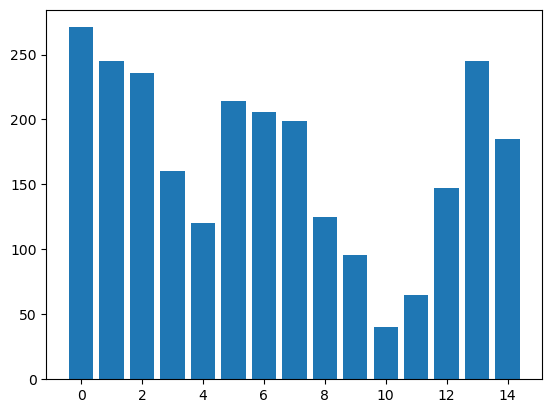

In [10]:
plt.bar(*torch.unique(groupsX, return_counts=True))

In [11]:
from sklearn.decomposition import NMF

def nmf_init(Y, n_components=15, normalize=True, device='cpu'):
    """
    Initialize latent space using NMF on data Y (torch.Tensor).

    Args:
        Y: torch.Tensor of shape (N, D)
        n_components: number of NMF factors
        normalize: whether to scale output like PCA
        device: output device

    Returns:
        X_nmf: torch.Tensor of shape (N, n_components)
    """
    Y_np = Y.detach().cpu().numpy()

    model = NMF(n_components=n_components, init='random', random_state=0, max_iter=500)
    W = model.fit_transform(Y_np)  # shape (N, n_components)

    X_nmf = torch.tensor(W, dtype=torch.float32, device=device)

    if normalize:
        # Scale like PCA-based init (optional)
        scale = torch.sqrt(torch.tensor(X_nmf.shape[0], dtype=torch.float32, device=device))
        X_nmf = X_nmf / X_nmf.norm(dim=0, keepdim=True) * scale

    return X_nmf

In [13]:
X = nmf_init(Y.T, n_components=30, normalize=True, device=Y.device)


/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


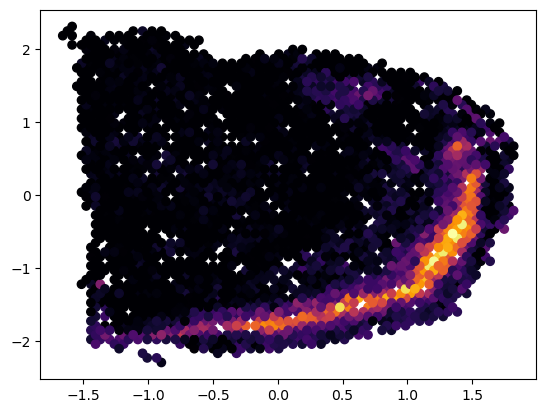

In [39]:
plt.scatter(Dtr['X'][:,0],Dtr['X'][:,1], c=X[:,25], cmap='inferno')

In [40]:
# U,S, V = torch.svd((Y-Y.mean(dim=1, keepdims=True)).T@(Y-Y.mean(dim=1, keepdims=True)))
# X = U[:,:15]*torch.sqrt(S[:15]/S[0])*np.sqrt(len(U))

In [42]:
X_average = torch.stack([torch.mean(torch.tensor(Dtr['X'])[groupsX==group], dim=0) for group in torch.unique(groupsX)])

In [44]:
# groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
# n_groups = len(adata.obs.cluster.values.categories)
M = 2554
L_dims = 2

jitter = 1e-5
kernel_gp = batched_MGGP_RBF(sigma=1.0, lengthscale=1.0, group_diff_param=10.0, n_groups=n_groups)

kernel_gp.set_group_distances(torch.cdist(X_average, X_average))

gp = MGGP_WSVGP(kernel_gp, M=M, jitter=jitter, n_groups=n_groups)
Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)

# mu = torch.randn((L_dims,M))
groupsZ = nn.Parameter(torch.tensor(groupsX).type(torch.LongTensor), requires_grad=False)


# mu = U[:,:L_dims]*np.sqrt(len(U))
# mu = mu.T


gp.Z = Z
gp.groupsZ = groupsZ
mu = gp.init_mean( X=X, mean=(X_average[groupsX]), groupsX=groupsX).T
# mu = gp.init_mean( X=X, mean=torch.tensor(Dtr['X']), groupsX=groupsX).T



mu += 0.1*torch.randn(mu.shape)

gp.mu = nn.Parameter(mu.detach().clone())
gp.Lu = nn.Parameter(1e-2*torch.eye(M).clone())





kernel = batched_RBF(sigma=1.0, lengthscale=1.0)


model = ChromGP(gp, kernel, noise=0.1, jitter=1e-4)




/tmp/ipykernel_3920692/1028434536.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_3920692/1028434536.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  groupsZ = nn.Parameter(torch.tensor(groupsX).type(torch.LongTensor), requires_grad=False)


torch.Size([2554, 2554])
torch.Size([2554, 2])


In [45]:
qF, _, _ = gp(X=X, groupsX=groupsX)
mean_init = qF.mean.T.detach()

/tmp/ipykernel_3920692/2516800549.py:27: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


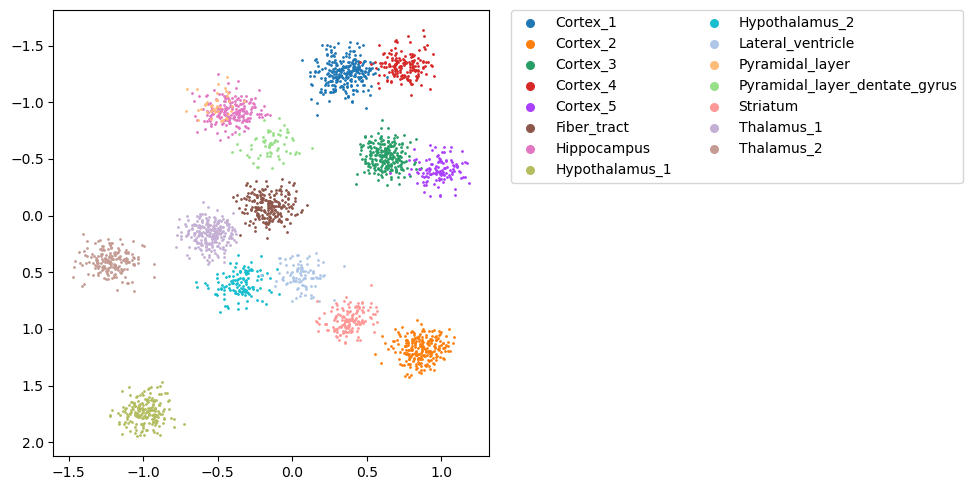

In [46]:
# Get colors directly from AnnData object
cluster_colors = adata.uns['cluster_colors']  # array of hex color codes
cluster_names = list(adata.obs.cluster.cat.categories)


plt.figure(figsize=(10, 5))
for i in range(n_groups):
    idx = groupsX == i
    plt.scatter(
        mean_init[idx][:, 0],
        mean_init[idx][:, 1],
        s=1.0,
        label=cluster_names[i],
        color=cluster_colors[i]  # Consistent with squidpy
    )

plt.gca().invert_yaxis()

legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(n_groups + 9) // 10
)

# Make legend dots bigger
for handle in legend.legendHandles:
    if hasattr(handle, "set_sizes"):
        handle.set_sizes([30])

plt.tight_layout()
plt.show()

In [47]:
def train_batched(optimizer, model, X, groupsX, y, device, steps=200, batch_size=1000, **kwargs):
    Zs = []

    # means = []
    # scales = []
    losses = []
    N = len(X)

    
    for it in tqdm(range(steps)):

        # idx = torch.multinomial(torch.ones(N), num_samples=batch_size, replacement=False)

        X_batch = X #+ 0.1*torch.randn(X.shape)#[idx]
        y_batch = y#[:, idx]
        groupsX_batch = groupsX#[idx]


        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        groupsX_batch = groupsX_batch.to(device)

        

        optimizer.zero_grad()

        
        pY, qZ, qU, pU = model(X_batch.squeeze(), groupsX=groupsX_batch, **kwargs)

        y_norm = y_batch- y_batch.mean(dim=1, keepdims=True)
        
        
        L1 = pY.log_prob(y_norm).sum()

        L1 = (L1*N)/batch_size
        L2 = torch.sum(torch.vmap(whitened_KL)(qU.mean, qU.scale_tril))
        # L2 =torch.sum(distributions.kl_divergence(qU, pU))

        log_prob = L1 - L2
        loss = -log_prob
        
        
        loss.backward()
        optimizer.step()        
        losses.append(loss.item())
        Zs.append(qZ.mean.T.detach().cpu().clone().numpy())



        X_batch = X_batch.cpu()
        y_batch = y_batch.cpu()
        groupsX_batch = groupsX_batch.cpu()

        del X_batch, y_batch, groupsX_batch

    
    with torch.no_grad():
        if device.type=='cuda':
            torch.cuda.empty_cache()

    return losses, Zs#, means, scales

In [48]:
model.gp.kernel.lengthscale.requires_grad = True
model.gp.kernel.group_diff_param.requires_grad = True
model.gp.kernel.sigma.requires_grad = False
model.kernel.lengthscale.requires_grad = False
model.kernel.sigma.requires_grad = False
model.gp.Lu.requires_grad=True
model.gp.mu.requires_grad=True

model.gp.jitter=1e-4
model.jitter=1e-4

In [49]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [50]:
def add_noise_mean(model, scale):
    with torch.no_grad():
        noise = scale * torch.randn_like(model.prior.mean)
        model.prior.mean.add_(noise)

# add_noise_mean(model, 1.0)

In [71]:
model.to(device)
losses, Zs = train_batched(optimizer=optimizer, model=model, X=X, groupsX=groupsX, y=Y, device=device, steps=9000, batch_size=Y.shape[1], diag=True)

  0%|          | 0/9000 [00:00<?, ?it/s]

In [72]:
model.gp.kernel.lengthscale

Parameter containing:
tensor(3.7974, device='cuda:1', requires_grad=True)

In [73]:
model.gp.kernel.group_diff_param

Parameter containing:
tensor(10.8738, device='cuda:1', requires_grad=True)

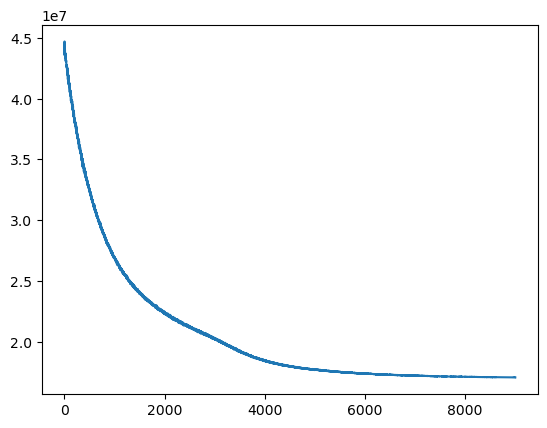

In [74]:
plt.plot(losses)

In [75]:
model.kernel.lengthscale

Parameter containing:
tensor(1., device='cuda:1')

In [76]:
Zs[-1]

array([[ 1.15093   ,  0.5742665 ],
       [ 0.94857514, -0.495898  ],
       [-1.099903  ,  1.1556053 ],
       ...,
       [ 0.40475205, -0.5120333 ],
       [ 0.68923736, -0.94956905],
       [-1.7579228 ,  1.0895059 ]], dtype=float32)

In [77]:
groupsX = torch.tensor(adata[Dtr['idx']].obs.cluster.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.cluster.values.categories)

In [78]:
Zs[0].shape

(2554, 2)

/tmp/ipykernel_3920692/3292430657.py:28: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


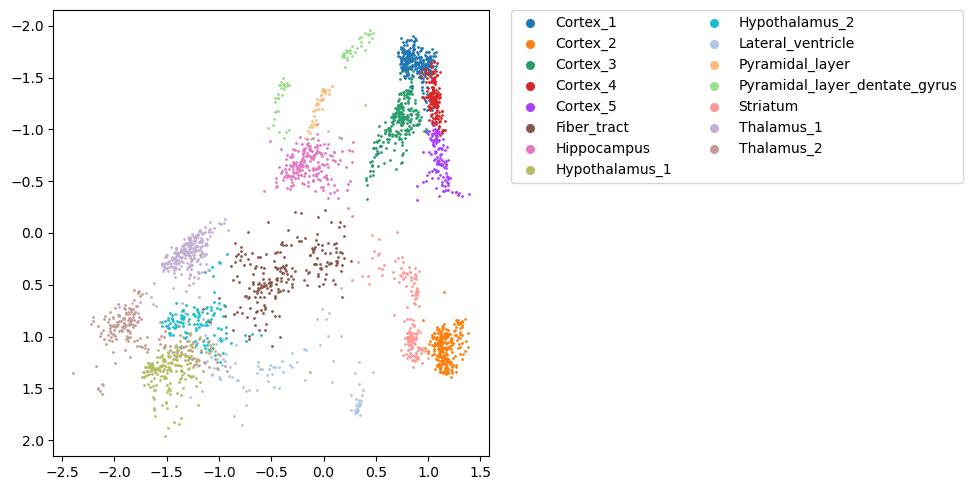

In [79]:
# Get colors directly from AnnData object
cluster_colors = adata.uns['cluster_colors']  # array of hex color codes
cluster_names = list(adata.obs.cluster.cat.categories)

curr_training_idx = -1

plt.figure(figsize=(10, 5))
for i in range(n_groups):
    idx = groupsX == i
    plt.scatter(
        Zs[curr_training_idx][idx][:, 0],
        Zs[curr_training_idx][idx][:, 1],
        s=1.0,
        label=cluster_names[i],
        color=cluster_colors[i]  # Consistent with squidpy
    )

plt.gca().invert_yaxis()

legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(n_groups + 9) // 10
)

# Make legend dots bigger
for handle in legend.legendHandles:
    if hasattr(handle, "set_sizes"):
        handle.set_sizes([30])

plt.tight_layout()
plt.show()

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


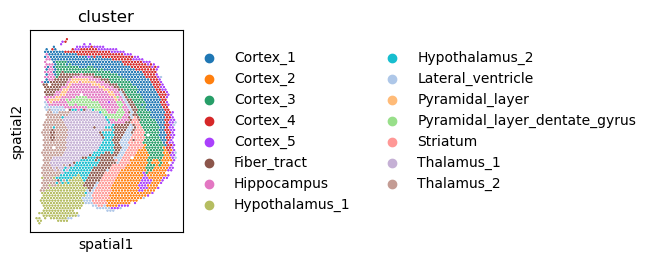

In [69]:
sq.pl.spatial_scatter(adata, color="cluster", size=1, shape=None);


In [70]:
torch.nn.functional.softplus(model.noise)

tensor(0.1859, device='cuda:1', grad_fn=<SoftplusBackward0>)